8759    489.64
1434    472.04
7320    448.92
2579    454.43
9142    482.49
Name: PE, dtype: float64
float64


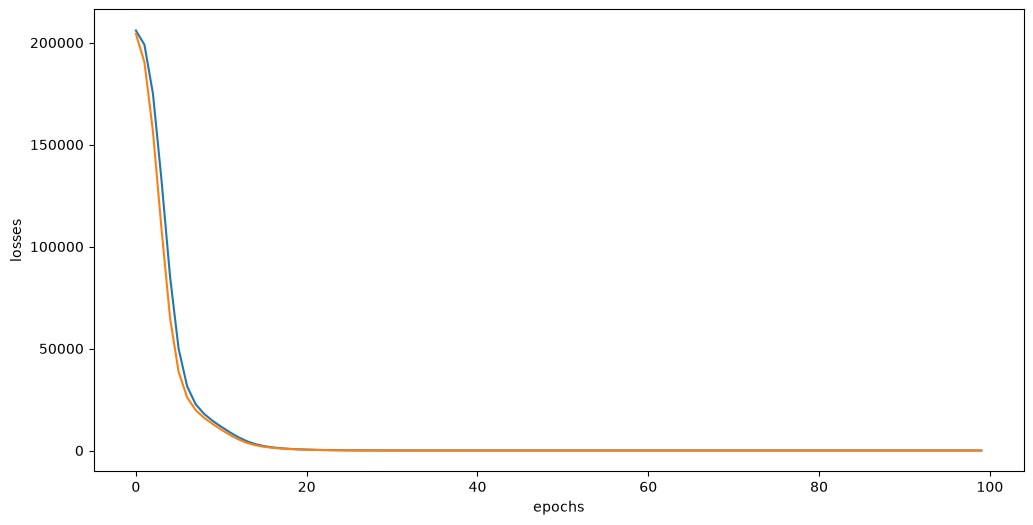

tensor(21.1502)
tensor(20.0973)
r2_score: 0.9302097430451685


In [1]:
from sklearn.preprocessing import StandardScaler
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
from torch.utils.data import DataLoader,TensorDataset
import torch.optim as optim 
import seaborn as sb
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
#Seeing the data for feature engineering applicable or not
df=pd.read_csv("Powerplant.csv")
X = df.drop("PE", axis=1)
y = df["PE"]

#splitting the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)
print(y_train.head())
#scaling the dataset
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# print(X_train_scaled)
print(y_test.dtype)
#making the dataset to tensor

X_train_tensor=torch.tensor(
    X_train_scaled,dtype=torch.float32
)
y_train_tensor=torch.tensor(
    y_train.values, dtype=torch.float32
).view(-1,1)
X_test_tensor=torch.tensor(
    X_test_scaled,dtype=torch.float32
)
y_test_tensor = torch.tensor(
    y_test.values, dtype=torch.float32
).view(-1,1)


#first get the raw data from tensorDataset

tensor_train_dataset=TensorDataset(X_train_tensor,y_train_tensor)
tensor_test_dataset=TensorDataset(X_test_tensor,y_test_tensor)

#DataLoader
train_loader=DataLoader(
    tensor_train_dataset,batch_size=32,shuffle=True
)
test_loader=DataLoader(
    tensor_test_dataset,batch_size=32,shuffle=False
)

#Defining ANN Model

class ANN(nn.Module):
    def __init__(self):
        super(ANN,self).__init__()
        
        self.model=nn.Sequential(
        #1st hidden layer
        nn.Linear(X_train.shape[1],6),
        nn.ReLU(),
        
        #2nd layer
        nn.Linear(6,6),
        nn.ReLU(),
        
        #3rd layer
        nn.Linear(6,1)
    )
    
    def forward(self,X):
        return self.model(X)
    
    
#optimization,Loss Calculation
model=ANN()
criterion=nn.MSELoss()
optimizer=optim.Adam(model.parameters())

#Training the ANN

train_losses=[]
val_losses=[]
best_val_loss=float("inf")
epochs=100

for epoch in range(epochs):
    model.train()
    running_loss=0.0 
    for xb,yb in train_loader:
        optimizer.zero_grad()    
        outputs=model(xb)
        
        loss=criterion(outputs,yb) #computing loss
        
        loss.backward()  #gradient calc
        
        optimizer.step() #updating params
        
        running_loss+=loss.item()
        
    epoch_train_loss=running_loss/len(train_loader)
    train_losses.append(epoch_train_loss)
        
   
#Now for validation 
    model.eval()
    running_val_loss=0.0
    with torch.no_grad():
        for xb,yb in test_loader:
            outputs=model(xb)
            loss=criterion(outputs,yb)
            running_val_loss+=loss.item()
            
    epoch_val_loss=running_val_loss/len(test_loader)
    val_losses.append(epoch_val_loss)
    if epoch_val_loss<best_val_loss:    
        best_val_loss=epoch_val_loss
        torch.save(model.state_dict(),"Mymodel.pt")
    # print(
    #     f"Epoch [{epoch+1}/{epochs}] "
    #     f"Train Loss: {epoch_train_loss:.4f} "
    #     f"Val Loss: {epoch_val_loss:.4f}"
    # )
    
#VISUALIZATION
plt.figure(figsize=(12,6))
plt.plot(train_losses,label="Training_losses")
plt.plot(val_losses,label="validation_losses")
plt.xlabel("epochs")
plt.ylabel("losses")
plt.show()


model.load_state_dict(torch.load("mymodel.pt"))


#Evaluation

model.eval()
with torch.no_grad():
    train_preds=model(X_train_tensor)
    test_preds=model(X_test_tensor)
    
    train_mse_loss=criterion(train_preds,y_train_tensor)
    test_mse_loss=criterion(test_preds,y_test_tensor)
    
print(train_mse_loss)
print(test_mse_loss)

print("r2_score:",r2_score(y_test,test_preds))
    